In [ ]:
# Install necessary packages
!pip install torch transformers datasets pandas matplotlib seaborn tqdm
!pip install einops  # Required by KDEformer

# Clone KDEformer repository
!git clone https://github.com/AlirezaSohrabiHT/kdeformer  # Replace with actual repo
%cd kdeformer

# Check for GPU availability
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
def free_gpu_memory():
    """Free GPU memory by emptying cache and running garbage collection"""
    import torch
    import gc

    # Print memory usage before cleanup
    if torch.cuda.is_available():
        print(f"Before cleanup: {torch.cuda.memory_allocated() / 1024**2:.2f} MB allocated, "
              f"{torch.cuda.memory_reserved() / 1024**2:.2f} MB reserved")

    # Clear PyTorch cache safely
    try:
        torch.cuda.empty_cache()
    except RuntimeError as e:
        print(f"Warning: Could not empty CUDA cache: {e}")
        print("Continuing with garbage collection only...")

    # Run Python garbage collector
    gc.collect()

    # Print memory usage after cleanup
    if torch.cuda.is_available():
        print(f"After cleanup: {torch.cuda.memory_allocated() / 1024**2:.2f} MB allocated, "
              f"{torch.cuda.memory_reserved() / 1024**2:.2f} MB reserved")

    # Additional memory stats if available
    try:
        free_mem, total_mem = torch.cuda.mem_get_info()
        print(f"GPU memory available: {free_mem / 1024**3:.2f} GB out of {total_mem / 1024**3:.2f} GB")
    except:
        print("Detailed memory info not available")

    return "Memory cleanup complete"

In [ ]:
# Import the KDEformer module
from KDEformer import KDEformer
from KDEformer import power_method

# Tuned version of KDEformer with improvements
class KDEformerTuned(KDEformer):
    def __init__(self, sample_size=1024, num_projs=10, Bucket_size=128, **kwargs):
        super().__init__(sample_size=sample_size, num_projs=num_projs, Bucket_size=Bucket_size, **kwargs)
        self.use_adaptive_sampling = True  # New feature

    def calc_A_res(self, key, query, Q_sort_idx, value, batch_size, head_size):
        # Optimize key calculation for better performance
        Gram_V = torch.einsum('bhnt,bhnd->bhtd', value, value)
        V_norm = power_method(Gram_V, itr_num=10).unsqueeze(2)  # Reduced iterations for speed

        # More balanced probability calculation
        P = torch.linalg.norm(value, dim=3) / (V_norm + 1e-8)  # Add epsilon to avoid division by zero
        P += torch.ones_like(P) / key.shape[2]

        # Normalize probabilities
        P = torch.nn.functional.normalize(P, p=1, dim=2)

        # Adaptive sampling based on sequence length
        if self.use_adaptive_sampling and key.shape[2] > 2048:
            # For longer sequences, increase sample size
            sample_size = min(self.sample_size * 2, key.shape[2] // 2)
        else:
            sample_size = self.sample_size

        Pflat = P.view(-1, P.shape[2])
        index = Pflat.multinomial(num_samples=sample_size, replacement=True)

        # Rest of the original implementation...
        num_blocks = key.shape[2] // self.Bucket_size
        bucket_size_query = query.shape[2] // num_blocks

        sampled_set = index.view(batch_size, head_size, -1)

        Offset = torch.zeros_like(sampled_set)
        n = key.shape[2]
        Offset += n * torch.arange(Offset.shape[1], device=query.device).unsqueeze(0).unsqueeze(-1)
        Offset += n * Offset.shape[1] * torch.arange(Offset.shape[0], device=query.device).unsqueeze(-1).unsqueeze(-1)
        sampled_set = (sampled_set + Offset).view(-1)

        block_id = torch.div(index, self.Bucket_size, rounding_mode='floor')
        bucket_member = Q_sort_idx.view(-1, bucket_size_query)

        Offset = torch.zeros_like(block_id)
        Offset += num_blocks * torch.arange(Offset.shape[0], device=query.device).unsqueeze(-1)
        block_sample = (block_id + Offset).view(-1)
        query_sample_collision = bucket_member[block_sample, :]

        Offset = torch.zeros_like(query_sample_collision)
        Offset += query.shape[2] * torch.arange(Offset.shape[0], device=query.device).unsqueeze(-1)
        query_sample_collision_flat = (query_sample_collision + Offset).view(-1)

        if self.mask_matrix is None:
            mask_matrix = torch.ones(batch_size, head_size, sample_size, query.shape[2]).view(-1).to(query.device)
        else:
            mask_matrix = self.mask_matrix.to(query.device)

        mask_matrix[query_sample_collision_flat] = 0
        mask_matrix = mask_matrix.view(batch_size, head_size, sample_size, query.shape[2])
        mask_matrix = torch.transpose(mask_matrix, 2, 3)

        # More efficient tensor operations
        Vpi = torch.index_select(value.view(-1, value.shape[3]), 0, sampled_set).view(
            batch_size, head_size, sample_size, value.shape[3])

        Kpi = torch.index_select(key.view(-1, key.shape[3]), 0, sampled_set).view(
            batch_size, head_size, sample_size, key.shape[3])

        Ppi = torch.index_select(P.view(-1), 0, sampled_set).view(batch_size, head_size, sample_size)
        sig = 1.0 / (Ppi * sample_size + 1e-8)  # Avoid division by zero

        # More numerically stable attention calculation
        dot_product = torch.einsum('bhnd,bhsd->bhns', query, Kpi)
        # Apply kernel trick for numerical stability
        max_vals = torch.max(dot_product, dim=-1, keepdim=True)[0]
        Api = torch.exp(dot_product - max_vals) * mask_matrix

        att_res = torch.einsum('bhns,bhsp->bhnp', Api, sig.unsqueeze(-1) * Vpi)

        return att_res

# Import other attention mechanisms for comparison
from Performer import PerformerAttention
from Reformer import ReformerAttention

# Define the standard attention module
import torch.nn as nn
import torch
import gc
# Define the standard attention module
class ExactAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, query, key, value):
        # Reshape for multi-head attention
        batch_size, seq_len, n_heads, head_dim = query.shape

        # Einsum notation for batch matrix multiplication with attention
        attention_scores = torch.einsum('bthd,bshd->btsh', query, key) / (head_dim ** 0.5)
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attention_output = torch.einsum('btsh,bshd->bthd', attention_weights, value)

        return attention_output

# Define safe forward as a separate function
def safe_forward(attn_module, q, k, v):
    """Safely handle attention forward pass with proper error checking"""
    # Ensure all input tensors are properly shaped and contiguous
    q = q.contiguous()
    k = k.contiguous()
    v = v.contiguous()

    # Check for NaN or Inf values
    if (torch.isnan(q).any() or torch.isnan(k).any() or torch.isnan(v).any() or
        torch.isinf(q).any() or torch.isinf(k).any() or torch.isinf(v).any()):
        print("Warning: NaN or Inf values detected in attention inputs")

        # Replace problematic values
        q = torch.nan_to_num(q, nan=0.0, posinf=1.0, neginf=-1.0)
        k = torch.nan_to_num(k, nan=0.0, posinf=1.0, neginf=-1.0)
        v = torch.nan_to_num(v, nan=0.0, posinf=1.0, neginf=-1.0)

        # Additional safety: normalize tensors
        q = torch.nn.functional.normalize(q, dim=-1, p=2, eps=1e-8)
        k = torch.nn.functional.normalize(k, dim=-1, p=2, eps=1e-8)

    try:
        # Try the original attention module
        return attn_module(q, k, v)
    except Exception as e:
        print(f"Error in attention forward pass: {e}")
        print("Falling back to standard attention")
        # Fall back to exact attention
        fallback = ExactAttention()
        return fallback(q, k, v)



In [ ]:
# Add these at the beginning of your script
import os
os.environ['TORCH_USE_CUDA_DSA'] = '1'  # Enable CUDA device-side assertions
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Makes CUDA errors synchronous for better debugging
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True,garbage_collection_threshold:0.6,max_split_size_mb:512'

# Then import torch and other libraries
import torch
# A100-specific optimizations
def optimize_for_a100():
    # Enable TF32 for faster matrix multiplications (A100 feature)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    # Enable cudnn benchmark for optimizing convolution algorithms
    torch.backends.cudnn.benchmark = True

    # Set optimal memory allocation strategy
    torch.cuda.empty_cache()

    # Enable asynchronous kernel launches
    torch.cuda.set_device(0)  # Use first GPU explicitly

    # Check A100 specific capabilities
    device_capability = torch.cuda.get_device_capability(0)
    print(f"GPU Compute Capability: {device_capability}")

    # Print available memory more safely
    try:
        free_mem, total_mem = torch.cuda.mem_get_info()
        print(f"Available GPU memory: {free_mem / 1024**3:.2f} GB out of {total_mem / 1024**3:.2f} GB")
    except (RuntimeError, AttributeError):
        # Fall back to a more basic memory report if mem_get_info is not available
        print("Could not get detailed memory info. Basic memory allocated:")
        print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
        print(f"Memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

    return device_capability[0] >= 8  # Return True if A100 or newer (SM 8.0+)

In [ ]:
import math
import torch
from einops import rearrange

class Performer_Att:
    def __init__(self, num_feats, dim, dev, dtype):
        self.num_feats = num_feats
        self.dim = dim
        # Orthogonal random features for better numerical stability
        weights = torch.randn(self.dim[0], self.dim[1], self.dim[2], self.num_feats, dtype=dtype, device=dev)
        # Normalize weights for better stability
        weights = weights / math.sqrt(self.dim[2])
        self.weights = weights

    def calc_feats(self, K):
        # Project K with numerically stable approach
        proj_K = torch.einsum('bhnd,bhdr -> bhnr', K, self.weights)

        # Calculate K norm with epsilon to avoid numerical issues
        K_norm = torch.sum(K.pow(2), axis=-1, keepdims=True) + 1e-10

        # Apply exponential with clipping to prevent overflow/underflow
        # This is critical for numerical stability
        exp_term = torch.clamp(proj_K - 0.5 * K_norm, min=-15.0, max=15.0)
        feats = torch.exp(exp_term) / math.sqrt(self.num_feats)

        # Add epsilon to avoid division by zero later
        feats = torch.max(feats, torch.ones_like(feats) * 1e-10)

        return feats


class SimpleStablePerformerAttention(torch.nn.Module):
    def __init__(self, num_feats=256, epsilon=1e-6, normalize=True, redraw_interval=1000):
        super().__init__()
        self.num_feats = num_feats
        self.epsilon = epsilon
        self.normalize = normalize
        self.redraw_interval = redraw_interval
        self.calls = 0

    def forward(self, query, key, value):
        # Ensure the input has the right shape
        b, t, h, d = query.shape
        _, s, _, _ = key.shape

        # Reshape for calculation
        query = query.permute(0, 2, 1, 3).contiguous()  # [b, h, t, d]
        key = key.permute(0, 2, 1, 3).contiguous()      # [b, h, s, d]
        value = value.permute(0, 2, 1, 3).contiguous()  # [b, h, s, d]

        # Optional normalization for better stability
        if self.normalize:
            query = query / torch.norm(query, dim=-1, keepdim=True).clamp(min=self.epsilon)
            key = key / torch.norm(key, dim=-1, keepdim=True).clamp(min=self.epsilon)

        # Create random projection matrix (stable version)
        self.calls += 1
        if not hasattr(self, 'projection') or (self.calls % self.redraw_interval == 0):
            self.projection = torch.randn(d, self.num_feats, device=query.device, dtype=query.dtype) / math.sqrt(d)

        try:
            # Project query and key with same projection matrix
            q_proj = torch.matmul(query, self.projection)  # [b, h, t, f]
            k_proj = torch.matmul(key, self.projection)    # [b, h, s, f]

            # Apply stable kernel approximation with clipping for numerical stability
            q_norm = torch.sum(query ** 2, dim=-1, keepdim=True) / 2.0
            k_norm = torch.sum(key ** 2, dim=-1, keepdim=True) / 2.0

            q_norm = torch.clamp(q_norm, max=15.0)
            k_norm = torch.clamp(k_norm, max=15.0)

            q_prime = torch.exp(q_proj - q_norm)  # [b, h, t, f]
            k_prime = torch.exp(k_proj - k_norm)  # [b, h, s, f]

            # Normalize by sqrt(num_feats)
            q_prime = q_prime / math.sqrt(self.num_feats)
            k_prime = k_prime / math.sqrt(self.num_feats)

            # Linear attention calculation
            kv = torch.matmul(k_prime.transpose(-2, -1), value)  # [b, h, f, d]
            qkv = torch.matmul(q_prime, kv)  # [b, h, t, d]

            # Normalization factor
            k_sum = k_prime.sum(dim=2, keepdim=False)  # [b, h, f]
            D = torch.matmul(q_prime, k_sum.unsqueeze(-1)) + self.epsilon  # [b, h, t, 1]

            # Apply normalization
            output = qkv / D

            # Reshape back to original format
            output = output.permute(0, 2, 1, 3).contiguous()  # [b, t, h, d]
            return output

        except Exception as e:
            print(f"Error in Performer attention: {e}")
            # Fallback to standard dot-product attention
            q_scaled = query / math.sqrt(d)
            attn = torch.matmul(q_scaled, key.transpose(-2, -1))  # [b, h, t, s]
            attn = torch.softmax(attn, dim=-1)
            output = torch.matmul(attn, value)  # [b, h, t, d]

            # Reshape back to original format
            output = output.permute(0, 2, 1, 3).contiguous()  # [b, t, h, d]
            return output

In [ ]:
import math
import torch
from einops import rearrange




class StablePerformerAttention(torch.nn.Module):
    def __init__(self, num_feats=256, epsilon=1e-6, normalize=True, redraw_interval=1000):
        super().__init__()
        self.num_feats = num_feats
        self.epsilon = epsilon
        self.normalize = normalize
        self.performer = None
        self.redraw_interval = redraw_interval
        self.calls = 0

    def forward(self, query, key, value):
        # Reshape tensors
        query = rearrange(query, 'b t h e -> b h t e').contiguous()
        key = rearrange(key, 'b s h e -> b h s e').contiguous()
        value = rearrange(value, 'b s h d -> b h s d').contiguous()

        # Check for NaN values and reset them
        if torch.isnan(query).any() or torch.isnan(key).any() or torch.isnan(value).any():
            query = torch.nan_to_num(query)
            key = torch.nan_to_num(key)
            value = torch.nan_to_num(value)

        # Optional normalization for better stability
        if self.normalize:
            query = query / torch.norm(query, dim=-1, keepdim=True).clamp(min=self.epsilon)
            key = key / torch.norm(key, dim=-1, keepdim=True).clamp(min=self.epsilon)

        # Only create new random features periodically to prevent NaN issues from
        # constantly changing projections
        self.calls += 1
        if self.performer is None or (self.calls % self.redraw_interval == 0):
            self.performer = Performer_Att(
                self.num_feats,
                (query.shape[0], query.shape[1], query.shape[3]),
                query.device,
                query.dtype
            )

        try:
            # Calculate features for query and key
            K_feats = self.performer.calc_feats(key)
            Q_feats = self.performer.calc_feats(query)

            # Check for NaN in features and reset if needed
            if torch.isnan(K_feats).any() or torch.isnan(Q_feats).any():
                K_feats = torch.nan_to_num(K_feats)
                Q_feats = torch.nan_to_num(Q_feats)

            # Compute normalization term with stability measures
            D_tilde = torch.einsum('bhnd,bhd->bhn', Q_feats, torch.sum(K_feats, dim=2))
            D_tilde = torch.clamp(D_tilde, min=self.epsilon)  # Prevent division by zero
            D_inverse = 1.0 / D_tilde

            # Compute kernel-based attention
            kv = torch.einsum('bhnm,bhmd->bhmd', K_feats, value)
            output = torch.einsum('bhnm,bhmd->bhnd', Q_feats, kv)
            output = output * D_inverse.unsqueeze(-1)

            # Return output in original format
            output = rearrange(output, 'b h t d -> b t h d')
            return output

        except Exception as e:
            print(f"Error in Performer attention: {e}")
            # Fallback to standard dot-product attention if performer fails
            attn = torch.einsum('bhqd,bhkd->bhqk', query, key) / math.sqrt(query.shape[-1])
            attn = torch.softmax(attn, dim=-1)
            output = torch.einsum('bhqk,bhkd->bhqd', attn, value)
            output = rearrange(output, 'b h t d -> b t h d')
            return output

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Makes CUDA errors synchronous for better debugging
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True
# A100-specific optimizations
torch.backends.cuda.matmul.allow_tf32 = True         # Use TF32 precision (A100 feature)
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True                # Auto-tuning for current hardware
torch.cuda.set_device(0)                             # Explicitly set device
os.environ['TORCH_USE_CUDA_DSA'] = '1'  # Enable CUDA device-side assertions
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Make CUDA errors synchronous for better debugging
# Find your existing ModularAttention class and replace it with this version
# Import the EnhancedKDEformer and other related functions
try:
    from enhanced_kdeformer import (
        EnhancedKDEformer,
        Angular_LSH,
        CosineHammingLSH,
        power_method
    )
except ImportError:
    print("Error importing EnhancedKDEformer. Creating a simple implementation instead.")
    # Define a simplified version that will work
    from einops import rearrange
    import torch

    # Simple implementation of key functions
    class EnhancedKDEformer(torch.nn.Module):
        def __init__(self, num_projs=12, Bucket_size=128, sample_size=2048, adaptive_sampling=True):
            super().__init__()
            self.num_projs = num_projs
            self.Bucket_size = Bucket_size
            self.sample_size = sample_size
            self.adaptive_sampling = adaptive_sampling

        def forward(self, query, key, value):
            # Reshape for multi-head attention
            query = rearrange(query, 'b t h e -> b h t e').contiguous()
            key = rearrange(key, 'b s h e -> b h s e').contiguous()
            value = rearrange(value, 'b s h d -> b h s d').contiguous()

            # Simple attention calculation as a fallback
            attn_scores = torch.einsum('bhqd,bhkd->bhqk', query, key) / (query.shape[-1] ** 0.5)
            attn_probs = torch.softmax(attn_scores, dim=-1)
            output = torch.einsum('bhqk,bhkd->bhqd', attn_probs, value)

            # Return to original format
            output = rearrange(output, 'b h t d -> b t h d')
            return output
class ModularAttention(nn.Module):
    def __init__(self, config, attention_type="exact"):
        super().__init__()
        self.n_embd = config.n_embd
        self.n_head = config.n_head
        self.dropout = config.dropout

        assert self.n_embd % self.n_head == 0
        self.head_dim = self.n_embd // self.n_head

        # Standard projections
        self.query = nn.Linear(self.n_embd, self.n_embd)
        self.key = nn.Linear(self.n_embd, self.n_embd)
        self.value = nn.Linear(self.n_embd, self.n_embd)
        self.attn_drop = nn.Dropout(self.dropout)
        self.proj = nn.Linear(self.n_embd, self.n_embd)
        self.proj_drop = nn.Dropout(self.dropout)

        # Attention mechanism selection
        self.attention_type = attention_type
        if attention_type == "exact":
            self.attn = ExactAttention()
        elif attention_type == "kdeformer":
            self.attn = EnhancedKDEformer(
                num_projs=8,  # Increased from 10 to 12
                Bucket_size=64,
                sample_size=512,  # Increased from 1024 to 2048
                adaptive_sampling=True  # New feature
            )
        elif attention_type == "performer":
            self.attn = SimpleStablePerformerAttention(
                num_feats=128,
                epsilon=1e-6,
                normalize=True,
                redraw_interval=1000  # Only redraw projections occasionally for stability
            )
        elif attention_type == "reformer":
            self.attn = ReformerAttention(bucket_size=64)

    def forward(self, x, mask=None):
        B, T, C = x.shape

        # Project queries, keys, values
        q = self.query(x).reshape(B, T, self.n_head, self.head_dim)
        k = self.key(x).reshape(B, T, self.n_head, self.head_dim)
        v = self.value(x).reshape(B, T, self.n_head, self.head_dim)

        # Make tensors contiguous for better CUDA performance
        q = q.contiguous()
        k = k.contiguous()
        v = v.contiguous()

        # Use safe_forward instead of direct call
        attn_output = safe_forward(self.attn, q, k, v)

        # Handle case where attention returns a tuple (like Reformer)
        if isinstance(attn_output, tuple):
            attn_output = attn_output[0]

        # Reshape and project to output dimension
        y = attn_output.reshape(B, T, C)
        y = self.proj(y)
        return self.proj_drop(y)

class Block(nn.Module):
    def __init__(self, config, attention_type="exact"):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.attn = ModularAttention(config, attention_type)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class GPTConfig:
    def __init__(self, vocab_size=50257, n_layer=6, n_head=8, n_embd=512,
                 dropout=0.1, max_seq_len=1024):
        self.vocab_size = vocab_size
        self.n_layer = n_layer
        self.n_head = n_head
        self.n_embd = n_embd
        self.dropout = dropout
        self.max_seq_len = max_seq_len

class GPT(nn.Module):
    def __init__(self, config, attention_type="exact"):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.max_seq_len, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config, attention_type) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Initialize weights
        self.apply(self._init_weights)
        # Tie weights
        self.transformer.wte.weight = self.lm_head.weight

        print(f"GPT model initialized with attention type: {attention_type}")
        self.attention_type = attention_type

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()

        # Get token embeddings and position embeddings
        pos = torch.arange(0, t, dtype=torch.long, device=device).unsqueeze(0)
        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)

        # Apply transformer blocks
        for block in self.transformer.h:
            x = block(x)

        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)

        # Calculate loss if targets are provided
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss

In [ ]:
from transformers import GPT2Tokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import time

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

def clear_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()  # Add import gc at the top

# Create a simple dataset (using a small portion of WikiText)
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length',
                                  max_length=max_length, return_tensors='pt')

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        return item

    def __len__(self):
        return len(self.encodings.input_ids)

# Load a small dataset
# Find your existing prepare_dataset function and replace it
def prepare_dataset(seq_length, batch_size=None):
    dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    texts = dataset['text'][:1000]  # Take only a small portion for quick testing

    # Filter out empty or very short texts
    filtered_texts = [text for text in texts if len(text) > 10]

    # Calculate optimal batch size if not provided
    if batch_size is None:
        if seq_length <= 2048:
            batch_size = max(8, int(32 * (1024 / seq_length)))
        elif seq_length <= 8192:
            batch_size = max(4, int(16 * (1024 / seq_length)))
        else:
            batch_size = max(2, int(8 * (1024 / seq_length)))

    # Create dataset with proper error handling
    # Use truncation and padding to handle variable length inputs
    tokenized_inputs = tokenizer(
        filtered_texts,
        truncation=True,
        padding='max_length',
        max_length=seq_length,
        return_tensors='pt'
    )

    # Verify inputs aren't empty
    if len(tokenized_inputs['input_ids']) == 0:
        raise ValueError("No valid inputs after tokenization")

    # Verify shapes
    print(f"Input shape: {tokenized_inputs['input_ids'].shape}")
    if tokenized_inputs['input_ids'].shape[1] != seq_length:
        raise ValueError(f"Expected sequence length {seq_length} but got {tokenized_inputs['input_ids'].shape[1]}")

    # Create proper dataset
    dataset = TextDataset(tokenized_inputs)

    # Create dataloader with appropriate settings
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True  # Important: avoid partial batches
    )

    print(f"Using batch size {batch_size} for sequence length {seq_length}")
    print(f"Created dataloader with {len(dataloader)} batches")
    return dataloader

class TextDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        # Make sure to return a valid item
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        return item

    def __len__(self):
        return len(self.encodings.input_ids)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

In [ ]:
# Find your existing evaluate_model function and replace it
def evaluate_model(model, dataloader, device):
    model.eval()
    total_loss = 0
    start_time = time.time()
    batches_processed = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            try:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)

                # Shift inputs and targets for next token prediction
                targets = input_ids.clone()
                targets[:, :-1] = input_ids[:, 1:]
                targets[:, -1] = input_ids[:, 0]

                # Use mixed precision for evaluation too
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    logits, loss = model(input_ids, targets)

                total_loss += loss.item()
                batches_processed += 1

                # Free memory
                del input_ids, attention_mask, targets, logits, loss
                torch.cuda.empty_cache()

            except RuntimeError as e:
                if 'out of memory' in str(e):
                    print(f"OOM during evaluation at batch {batch_idx}. Skipping.")
                    torch.cuda.empty_cache()
                    continue
                else:
                    raise e

    if batches_processed == 0:
        return {'loss': float('nan'), 'perplexity': float('nan')}

    avg_loss = total_loss / batches_processed
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    elapsed_time = time.time() - start_time

    return {
        'loss': avg_loss,
        'perplexity': perplexity,
        'eval_time': elapsed_time,
        'eval_time_per_batch': elapsed_time / len(dataloader)
    }

# Find your existing train_model function and replace it
def train_model(model, dataloader, device, epochs=2):
    model.train()
    # Enable gradient checkpointing to save memory
    if hasattr(model, 'transformer'):
        model.gradient_checkpointing_enable()
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    # Add mixed precision for better performance
    scaler = torch.amp.GradScaler()

    training_stats = []
    total_training_time = 0

    for epoch in range(epochs):
        epoch_stats = {'epoch': epoch + 1, 'batch_times': []}
        epoch_start_time = time.time()
        total_loss = 0

        for batch_idx, batch in enumerate(dataloader):
            torch.cuda.synchronize()  # For accurate timing
            batch_start_time = time.time()

            # Zero gradients at the beginning of each batch
            optimizer.zero_grad()

            try:
                input_ids = batch['input_ids'].to(device)

                # Shift inputs and targets for next token prediction
                targets = input_ids.clone()
                targets[:, :-1] = input_ids[:, 1:]
                targets[:, -1] = input_ids[:, 0]

                # Forward pass with mixed precision
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    logits, loss = model(input_ids, targets)

                # Backward pass with gradient scaling
                scaler.scale(loss).backward()

                # Gradient clipping for stability
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                scaler.step(optimizer)
                scaler.update()

                total_loss += loss.item()

                torch.cuda.synchronize()  # For accurate timing
                batch_time = time.time() - batch_start_time
                epoch_stats['batch_times'].append(batch_time)

                if batch_idx % 10 == 0:
                    print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}, Time: {batch_time:.4f}s")

                # Free memory
                del input_ids, targets, logits, loss
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            except RuntimeError as e:
                error_msg = str(e)
                print(f"Error in batch {batch_idx}: {error_msg}")
                if 'out of memory' in error_msg:
                    print(f"OOM error. Skipping this batch.")
                    torch.cuda.empty_cache()
                    continue
                else:
                    raise e

        epoch_time = time.time() - epoch_start_time
        total_training_time += epoch_time

        epoch_stats.update({
            'avg_loss': total_loss / len(dataloader),
            'epoch_time': epoch_time,
            'avg_batch_time': sum(epoch_stats['batch_times']) / len(epoch_stats['batch_times']),
        })

        training_stats.append(epoch_stats)
        print(f"Epoch {epoch+1} completed in {epoch_time:.2f}s. Avg loss: {epoch_stats['avg_loss']:.4f}")

    return {
        'training_stats': training_stats,
        'total_training_time': total_training_time,
        'avg_epoch_time': total_training_time / epochs
    }


def improved_train_model(model, dataloader, device, epochs=3,
                     learning_rate=3e-5, warmup_steps=200, weight_decay=0.01):
    """
    Improved training function with linear warmup and cosine decay
    """
    model.train()

    # Total number of training steps
    num_batches = len(dataloader)
    total_steps = epochs * num_batches

    # Get model parameters
    param_optimizer = list(model.named_parameters())
    no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
    optimizer_grouped_parameters = [
        {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
         'weight_decay': weight_decay},
        {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
         'weight_decay': 0.0}
    ]

    # Better optimizer with weight decay
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=learning_rate)

    # Linear warmup and cosine decay
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Gradient scaler for mixed precision training
    scaler = torch.amp.GradScaler()

    training_stats = []
    best_loss = float('inf')

    # Initialize progress tracking
    global_step = 0
    total_loss = 0
    log_loss = 0

    for epoch in range(epochs):
        epoch_stats = {'epoch': epoch + 1, 'batch_times': []}
        epoch_start_time = time.time()

        # Training loop
        for batch_idx, batch in enumerate(dataloader):
            torch.cuda.synchronize()
            batch_start_time = time.time()

            optimizer.zero_grad()

            try:
                input_ids = batch['input_ids'].to(device)

                # Shift targets for next token prediction
                targets = input_ids.clone()
                targets[:, :-1] = input_ids[:, 1:]
                targets[:, -1] = input_ids[:, 0]

                # Mixed precision forward pass
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    logits, loss = model(input_ids, targets)

                # Scale loss and backpropagate
                scaler.scale(loss).backward()

                # Gradient clipping for stability
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                # Update weights
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

                # Accumulate loss statistics
                total_loss += loss.item()
                log_loss += loss.item()

                torch.cuda.synchronize()
                batch_time = time.time() - batch_start_time
                epoch_stats['batch_times'].append(batch_time)

                # Log progress
                global_step += 1
                if global_step % 10 == 0:
                    avg_loss = log_loss / 10
                    log_loss = 0

                    # Calculate learning rate
                    curr_lr = scheduler.get_last_lr()[0]

                    print(f"Epoch {epoch+1}/{epochs}, Step {global_step}/{total_steps}, "
                          f"Loss: {avg_loss:.4f}, LR: {curr_lr:.6f}, Time: {batch_time:.4f}s")

                # Free memory
                del input_ids, targets, logits, loss
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            except RuntimeError as e:
                error_msg = str(e)
                print(f"Error in batch {batch_idx}: {error_msg}")
                if 'out of memory' in error_msg:
                    print(f"OOM error. Skipping this batch and reducing batch size.")
                    torch.cuda.empty_cache()

                    # Try to reduce batch size dynamically for next batch
                    if hasattr(dataloader, 'batch_sampler') and hasattr(dataloader.batch_sampler, 'batch_size'):
                        if dataloader.batch_sampler.batch_size > 1:
                            new_batch_size = dataloader.batch_sampler.batch_size // 2
                            print(f"Reducing batch size to {new_batch_size}")
                            dataloader.batch_sampler.batch_size = new_batch_size
                    continue
                else:
                    raise e

        # Epoch statistics
        epoch_time = time.time() - epoch_start_time
        avg_epoch_loss = total_loss / len(dataloader)

        epoch_stats.update({
            'avg_loss': avg_epoch_loss,
            'epoch_time': epoch_time,
            'avg_batch_time': sum(epoch_stats['batch_times']) / len(epoch_stats['batch_times'])
        })

        training_stats.append(epoch_stats)
        print(f"Epoch {epoch+1} completed in {epoch_time:.2f}s. Avg loss: {avg_epoch_loss:.4f}")

        # Save best model
        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"New best model saved with loss: {best_loss:.4f}")

    return {
        'training_stats': training_stats,
        'total_training_time': sum(stat['epoch_time'] for stat in training_stats),
        'avg_epoch_time': sum(stat['epoch_time'] for stat in training_stats) / epochs,
        'best_loss': best_loss
    }

# Learning rate scheduler with warmup
from torch.optim.lr_scheduler import LambdaLR
import math

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5):
    def lr_lambda(current_step):
        # Warmup
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        # Cosine decay
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress)))

    return LambdaLR(optimizer, lr_lambda)

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import gc

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define sequence lengths to test
#seq_lengths = [1024, 2048, 4096, 8192, 16384]  # Added 16384 for A100
seq_lengths = [1024, 2048 ]  # Added 16384 for A100
# Define attention mechanisms to test
attention_types = ["exact", "kdeformer", "performer", "reformer"]

# Create results containers
results = {
    'training': [],
    'evaluation': [],
    'memory': []
}

# Run experiments for each sequence length and attention type
for seq_len in seq_lengths:
    print(f"\n--- Testing with sequence length: {seq_len} ---")

    # Prepare dataset
    dataloader = prepare_dataset(seq_len)

    for attn_type in attention_types:
        print(f"\nTesting attention type: {attn_type}")

        if attn_type == "exact" and seq_len > 8192:
            print(f"Skipping {attn_type} at length {seq_len} - would be too memory intensive")
            continue

        # Skip performer at very long sequences
        if attn_type == "performer" and seq_len > 8192:
            print(f"Skipping {attn_type} at length {seq_len} - known compatibility issues")
            continue

        try:
            # Reset CUDA memory
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            # Create model
            config = GPTConfig(
                n_layer=4,
                n_head=8,
                n_embd=384,
                max_seq_len=seq_len
            )
            model = GPT(config, attention_type=attn_type).to(device)

            # Track memory before training
            if torch.cuda.is_available():
                memory_before = torch.cuda.memory_allocated() / (1024 ** 2)

            # Train model
            training_results = improved_train_model(
                model=model,
                dataloader=dataloader,
                device=device,
                epochs=3,                # Increased from 2 to 3 epochs
                learning_rate=3e-5,      # Optimized learning rate
                warmup_steps=200,        # Add warmup for better training stability
                weight_decay=0.01        # Add weight decay to prevent overfitting
            )
            # Track memory after training
            if torch.cuda.is_available():
                memory_after = torch.cuda.memory_allocated() / (1024 ** 2)
                memory_used = memory_after - memory_before
            else:
                memory_used = 0

            # Evaluate model
            eval_results = evaluate_model(model, dataloader, device)

            # Store results
            for epoch_stats in training_results['training_stats']:
                results['training'].append({
                    'sequence_length': seq_len,
                    'attention_type': attn_type,
                    'epoch': epoch_stats['epoch'],
                    'loss': epoch_stats['avg_loss'],
                    'epoch_time': epoch_stats['epoch_time'],
                    'avg_batch_time': epoch_stats['avg_batch_time']
                })

            results['evaluation'].append({
                'sequence_length': seq_len,
                'attention_type': attn_type,
                'perplexity': eval_results['perplexity'],
                'eval_time': eval_results['eval_time'],
                'eval_time_per_batch': eval_results['eval_time_per_batch']
            })

            results['memory'].append({
                'sequence_length': seq_len,
                'attention_type': attn_type,
                'memory_used_mb': memory_used
            })

            pd.DataFrame(results['training']).to_csv('training_results_partial.csv', index=False)
            pd.DataFrame(results['evaluation']).to_csv('eval_results_partial.csv', index=False)

        except Exception as e:
            print(f"Error with {attn_type} at length {seq_len}: {e}")
            # Still save what we have
            pd.DataFrame(results['training']).to_csv(f'training_results_error_{seq_len}_{attn_type}.csv', index=False)
            continue

# Convert results to DataFrames
training_df = pd.DataFrame(results['training'])
eval_df = pd.DataFrame(results['evaluation'])
memory_df = pd.DataFrame(results['memory'])

# Save results
training_df.to_csv('training_results.csv', index=False)
eval_df.to_csv('evaluation_results.csv', index=False)
memory_df.to_csv('memory_results.csv', index=False)

Using device: cuda

--- Testing with sequence length: 1024 ---


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/733k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/6.36M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Input shape: torch.Size([647, 1024])
Using batch size 32 for sequence length 1024
Created dataloader with 20 batches

Testing attention type: exact
GPT model initialized with attention type: exact
Epoch 1/3, Step 10/60, Loss: 10.3173, LR: 0.000002, Time: 0.8738s
Epoch 1/3, Step 20/60, Loss: 9.9309, LR: 0.000003, Time: 0.8713s
Epoch 1 completed in 17.74s. Avg loss: 10.1241
New best model saved with loss: 10.1241
Epoch 2/3, Step 30/60, Loss: 9.1695, LR: 0.000005, Time: 0.8840s
Epoch 2/3, Step 40/60, Loss: 8.1243, LR: 0.000006, Time: 0.8705s
Epoch 2 completed in 17.30s. Avg loss: 18.7710
Epoch 3/3, Step 50/60, Loss: 6.9722, LR: 0.000008, Time: 0.8707s
Epoch 3/3, Step 60/60, Loss: 5.8768, LR: 0.000009, Time: 0.8710s
Epoch 3 completed in 17.77s. Avg loss: 25.1955

Testing attention type: kdeformer
GPT model initialized with attention type: kdeformer
Epoch 1/3, Step 10/60, Loss: 9.7612, LR: 0.000002, Time: 1.5322s
Epoch 1/3, Step 20/60, Loss: 9.1490, LR: 0.000003, Time: 1.5724s
Epoch 1 compl

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

def benchmark_attention_mechanisms(seq_lengths, attention_types, n_layer=4, n_head=8,
                                  n_embd=512, batch_size=None, epochs=2, device=None):
    """
    Comprehensive benchmarking function for different attention mechanisms
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Results containers with more metrics
    results = {
        'training': [],
        'evaluation': [],
        'memory': [],
        'throughput': [],
        'efficiency': []
    }

    # Run experiments for each sequence length and attention type
    for seq_len in seq_lengths:
        print(f"\n{'='*50}")
        print(f"Testing with sequence length: {seq_len}")
        print(f"{'='*50}")

        # Calculate optimal batch size for this sequence length
        if batch_size is None:
            if seq_len <= 2048:
                optimal_batch_size = max(8, int(32 * (1024 / seq_len)))
            elif seq_len <= 8192:
                optimal_batch_size = max(4, int(16 * (1024 / seq_len)))
            else:
                optimal_batch_size = max(2, int(8 * (1024 / seq_len)))
        else:
            optimal_batch_size = batch_size

        print(f"Using batch size {optimal_batch_size} for sequence length {seq_len}")

        # Prepare dataset with the calculated batch size
        dataloader = prepare_dataset(seq_len, batch_size=optimal_batch_size)

        for attn_type in attention_types:
            print(f"\n{'-'*40}")
            print(f"Testing attention type: {attn_type}")
            print(f"{'-'*40}")

            # Skip exact attention for very long sequences
            if attn_type == "exact" and seq_len > 8192:
                print(f"Skipping {attn_type} at length {seq_len} - would be too memory intensive")
                continue

            # Skip performer at very long sequences
            if attn_type == "performer" and seq_len > 8192:
                print(f"Skipping {attn_type} at length {seq_len} - known compatibility issues")
                continue

            try:
                # Reset CUDA memory
                clear_gpu_memory()

                # Record starting memory
                if torch.cuda.is_available():
                    torch.cuda.reset_peak_memory_stats()
                    memory_before = torch.cuda.memory_allocated() / (1024 ** 2)

                # Create model with appropriate size for sequence length
                config = GPTConfig(
                    n_layer=n_layer,
                    n_head=n_head,
                    n_embd=n_embd,
                    max_seq_len=seq_len
                )
                model = GPT(config, attention_type=attn_type).to(device)

                # Count parameters
                total_params = sum(p.numel() for p in model.parameters())
                print(f"Model has {total_params/1e6:.2f}M parameters")

                # Record compilation time for A100
                compile_start = time.time()
                if torch.cuda.get_device_capability(0)[0] >= 8:  # A100 or newer
                    try:
                        model = torch.compile(model)
                        print("Model compiled with torch.compile()")
                    except Exception as e:
                        print(f"Compilation failed: {e}")
                compile_time = time.time() - compile_start

                # Warmup pass
                print("Running warmup pass...")
                with torch.no_grad():
                    for batch in [next(iter(dataloader))]:
                        input_ids = batch['input_ids'].to(device)
                        model(input_ids)
                print("Warmup complete")

                # Train model with improved training
                print("Starting training...")
                training_start = time.time()
                training_results = improved_train_model(model, dataloader, device, epochs=epochs)
                training_time = time.time() - training_start

                # Record peak memory usage
                if torch.cuda.is_available():
                    peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)
                    memory_used = peak_memory - memory_before
                else:
                    memory_used = 0

                # Evaluate model
                print("Evaluating model...")
                eval_start = time.time()
                eval_results = evaluate_model(model, dataloader, device)
                eval_time = time.time() - eval_start

                # Calculate throughput (tokens/sec)
                tokens_per_batch = optimal_batch_size * seq_len
                total_tokens = tokens_per_batch * len(dataloader) * epochs
                training_throughput = total_tokens / training_time
                eval_throughput = tokens_per_batch * len(dataloader) / eval_time

                # Calculate efficiency (tokens/sec/MB)
                memory_efficiency = training_throughput / (memory_used + 1)  # Add 1 to avoid division by zero

                # Store detailed results
                for epoch_stats in training_results['training_stats']:
                    results['training'].append({
                        'sequence_length': seq_len,
                        'attention_type': attn_type,
                        'epoch': epoch_stats['epoch'],
                        'loss': epoch_stats['avg_loss'],
                        'epoch_time': epoch_stats['epoch_time'],
                        'avg_batch_time': epoch_stats['avg_batch_time'],
                        'batch_size': optimal_batch_size,
                        'param_count': total_params
                    })

                results['evaluation'].append({
                    'sequence_length': seq_len,
                    'attention_type': attn_type,
                    'perplexity': eval_results['perplexity'],
                    'loss': eval_results['loss'],
                    'eval_time': eval_results['eval_time'],
                    'eval_time_per_batch': eval_results['eval_time_per_batch'],
                    'batch_size': optimal_batch_size
                })

                results['memory'].append({
                    'sequence_length': seq_len,
                    'attention_type': attn_type,
                    'memory_used_mb': memory_used,
                    'peak_memory_mb': peak_memory,
                    'batch_size': optimal_batch_size
                })

                results['throughput'].append({
                    'sequence_length': seq_len,
                    'attention_type': attn_type,
                    'training_tokens_per_sec': training_throughput,
                    'eval_tokens_per_sec': eval_throughput,
                    'batch_size': optimal_batch_size,
                    'compile_time': compile_time
                })

                results['efficiency'].append({
                    'sequence_length': seq_len,
                    'attention_type': attn_type,
                    'tokens_per_sec_per_mb': memory_efficiency,
                    'tokens_per_sec_per_param': training_throughput / (total_params + 1),
                    'batch_size': optimal_batch_size
                })

                # Save partial results
                for key in results:
                    pd.DataFrame(results[key]).to_csv(f'{key}_results_partial.csv', index=False)

                print(f"Completed {attn_type} with length {seq_len}")
                print(f"  - Training throughput: {training_throughput:.2f} tokens/sec")
                print(f"  - Memory used: {memory_used:.2f} MB")
                print(f"  - Final loss: {training_results['best_loss']:.4f}")

            except Exception as e:
                print(f"Error with {attn_type} at length {seq_len}: {e}")
                # Save what we have
                for key in results:
                    pd.DataFrame(results[key]).to_csv(f'{key}_results_error_{seq_len}_{attn_type}.csv', index=False)
                continue

    # Convert results to DataFrames
    result_dfs = {}
    for key in results:
        result_dfs[key] = pd.DataFrame(results[key])
        result_dfs[key].to_csv(f'{key}_results.csv', index=False)

    # Generate comprehensive visualizations
    visualize_benchmark_results(result_dfs)

    return result_dfs

def visualize_benchmark_results(results):
    """
    Create comprehensive visualizations for benchmark results
    """
    # Set attractive plotting style
    sns.set(style="whitegrid", palette="muted", font_scale=1.2)
    plt.figure(figsize=(24, 20))

    # 1. Training time vs sequence length (log-log plot)
    plt.subplot(3, 3, 1)
    sns.lineplot(data=results['training'], x='sequence_length', y='avg_batch_time',
                 hue='attention_type', marker='o', errorbar=None)
    plt.xscale('log', base=2)
    plt.yscale('log', base=2)
    plt.title('Training Time vs Sequence Length (log-log)')
    plt.xlabel('Sequence Length')
    plt.ylabel('Time per Batch (s)')
    plt.grid(True, which="both", ls="-")

    # 2. Memory usage vs sequence length
    plt.subplot(3, 3, 2)
    sns.lineplot(data=results['memory'], x='sequence_length', y='memory_used_mb',
                 hue='attention_type', marker='o', errorbar=None)
    plt.xscale('log', base=2)
    plt.yscale('log', base=2)
    plt.title('Memory Usage vs Sequence Length')
    plt.xlabel('Sequence Length')
    plt.ylabel('Memory Usage (MB)')
    plt.grid(True, which="both", ls="-")

    # 3. Perplexity vs sequence length
    plt.subplot(3, 3, 3)
    sns.lineplot(data=results['evaluation'], x='sequence_length', y='perplexity',
                 hue='attention_type', marker='o', errorbar=None)
    plt.title('Perplexity vs Sequence Length')
    plt.xlabel('Sequence Length')
    plt.ylabel('Perplexity')
    plt.grid(True)

    # 4. Training throughput (tokens/sec)
    plt.subplot(3, 3, 4)
    sns.lineplot(data=results['throughput'], x='sequence_length', y='training_tokens_per_sec',
                 hue='attention_type', marker='o', errorbar=None)
    plt.title('Training Throughput')
    plt.xlabel('Sequence Length')
    plt.ylabel('Tokens per Second')
    plt.grid(True)

    # 5. Memory efficiency
    plt.subplot(3, 3, 5)
    sns.lineplot(data=results['efficiency'], x='sequence_length', y='tokens_per_sec_per_mb',
                 hue='attention_type', marker='o', errorbar=None)
    plt.title('Memory Efficiency')
    plt.xlabel('Sequence Length')
    plt.ylabel('Tokens/Sec per MB')
    plt.grid(True)

    # 6. Attention mechanism scaling comparison
    plt.subplot(3, 3, 6)
    # Calculate relative speedup vs exact attention
    speedup_data = []
    for seq_len in results['evaluation']['sequence_length'].unique():
        exact_time = results['evaluation'][
            (results['evaluation']['attention_type'] == 'exact') &
            (results['evaluation']['sequence_length'] == seq_len)
        ]['eval_time_per_batch'].values

        if len(exact_time) == 0:
            continue

        exact_time = exact_time[0]

        for attn_type in results['evaluation']['attention_type'].unique():
            if attn_type == 'exact':
                continue

            attn_times = results['evaluation'][
                (results['evaluation']['attention_type'] == attn_type) &
                (results['evaluation']['sequence_length'] == seq_len)
            ]['eval_time_per_batch'].values

            if len(attn_times) == 0:
                continue

            attn_time = attn_times[0]
            speedup = exact_time / attn_time

            speedup_data.append({
                'sequence_length': seq_len,
                'attention_type': attn_type,
                'speedup': speedup
            })

    if speedup_data:
        speedup_df = pd.DataFrame(speedup_data)
        sns.lineplot(data=speedup_df, x='sequence_length', y='speedup',
                    hue='attention_type', marker='o', errorbar=None)
        plt.title('Speedup Relative to Exact Attention')
        plt.xlabel('Sequence Length')
        plt.ylabel('Speedup Factor (higher is better)')
        plt.axhline(y=1.0, color='r', linestyle='--')
        plt.grid(True)

    # 7. Training convergence (loss vs epoch)
    plt.subplot(3, 3, 7)
    pivot_df = results['training'].pivot_table(
        index=['attention_type', 'epoch'],
        columns='sequence_length',
        values='loss'
    ).reset_index()

    for attn_type in pivot_df['attention_type'].unique():
        subset = pivot_df[pivot_df['attention_type'] == attn_type]
        plt.plot(subset['epoch'], subset[subset.columns[2]],
                marker='o', label=f"{attn_type}")

    plt.title('Training Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 8. Loss vs Sequence Length (final epoch)
    plt.subplot(3, 3, 8)
    max_epoch = results['training']['epoch'].max()
    last_epoch_df = results['training'][results['training']['epoch'] == max_epoch]

    sns.lineplot(data=last_epoch_df, x='sequence_length', y='loss',
                hue='attention_type', marker='o', errorbar=None)
    plt.title(f'Final Loss (Epoch {max_epoch})')
    plt.xlabel('Sequence Length')
    plt.ylabel('Loss')
    plt.grid(True)

    # 9. Computational Efficiency
    plt.subplot(3, 3, 9)
    sns.scatterplot(data=results['memory'],
                    x='memory_used_mb',
                    y=results['throughput']['training_tokens_per_sec'],
                    hue='attention_type',
                    size='sequence_length',
                    sizes=(100, 1000),
                    alpha=0.7)
    plt.title('Computational Efficiency')
    plt.xlabel('Memory Usage (MB)')
    plt.ylabel('Throughput (Tokens/sec)')

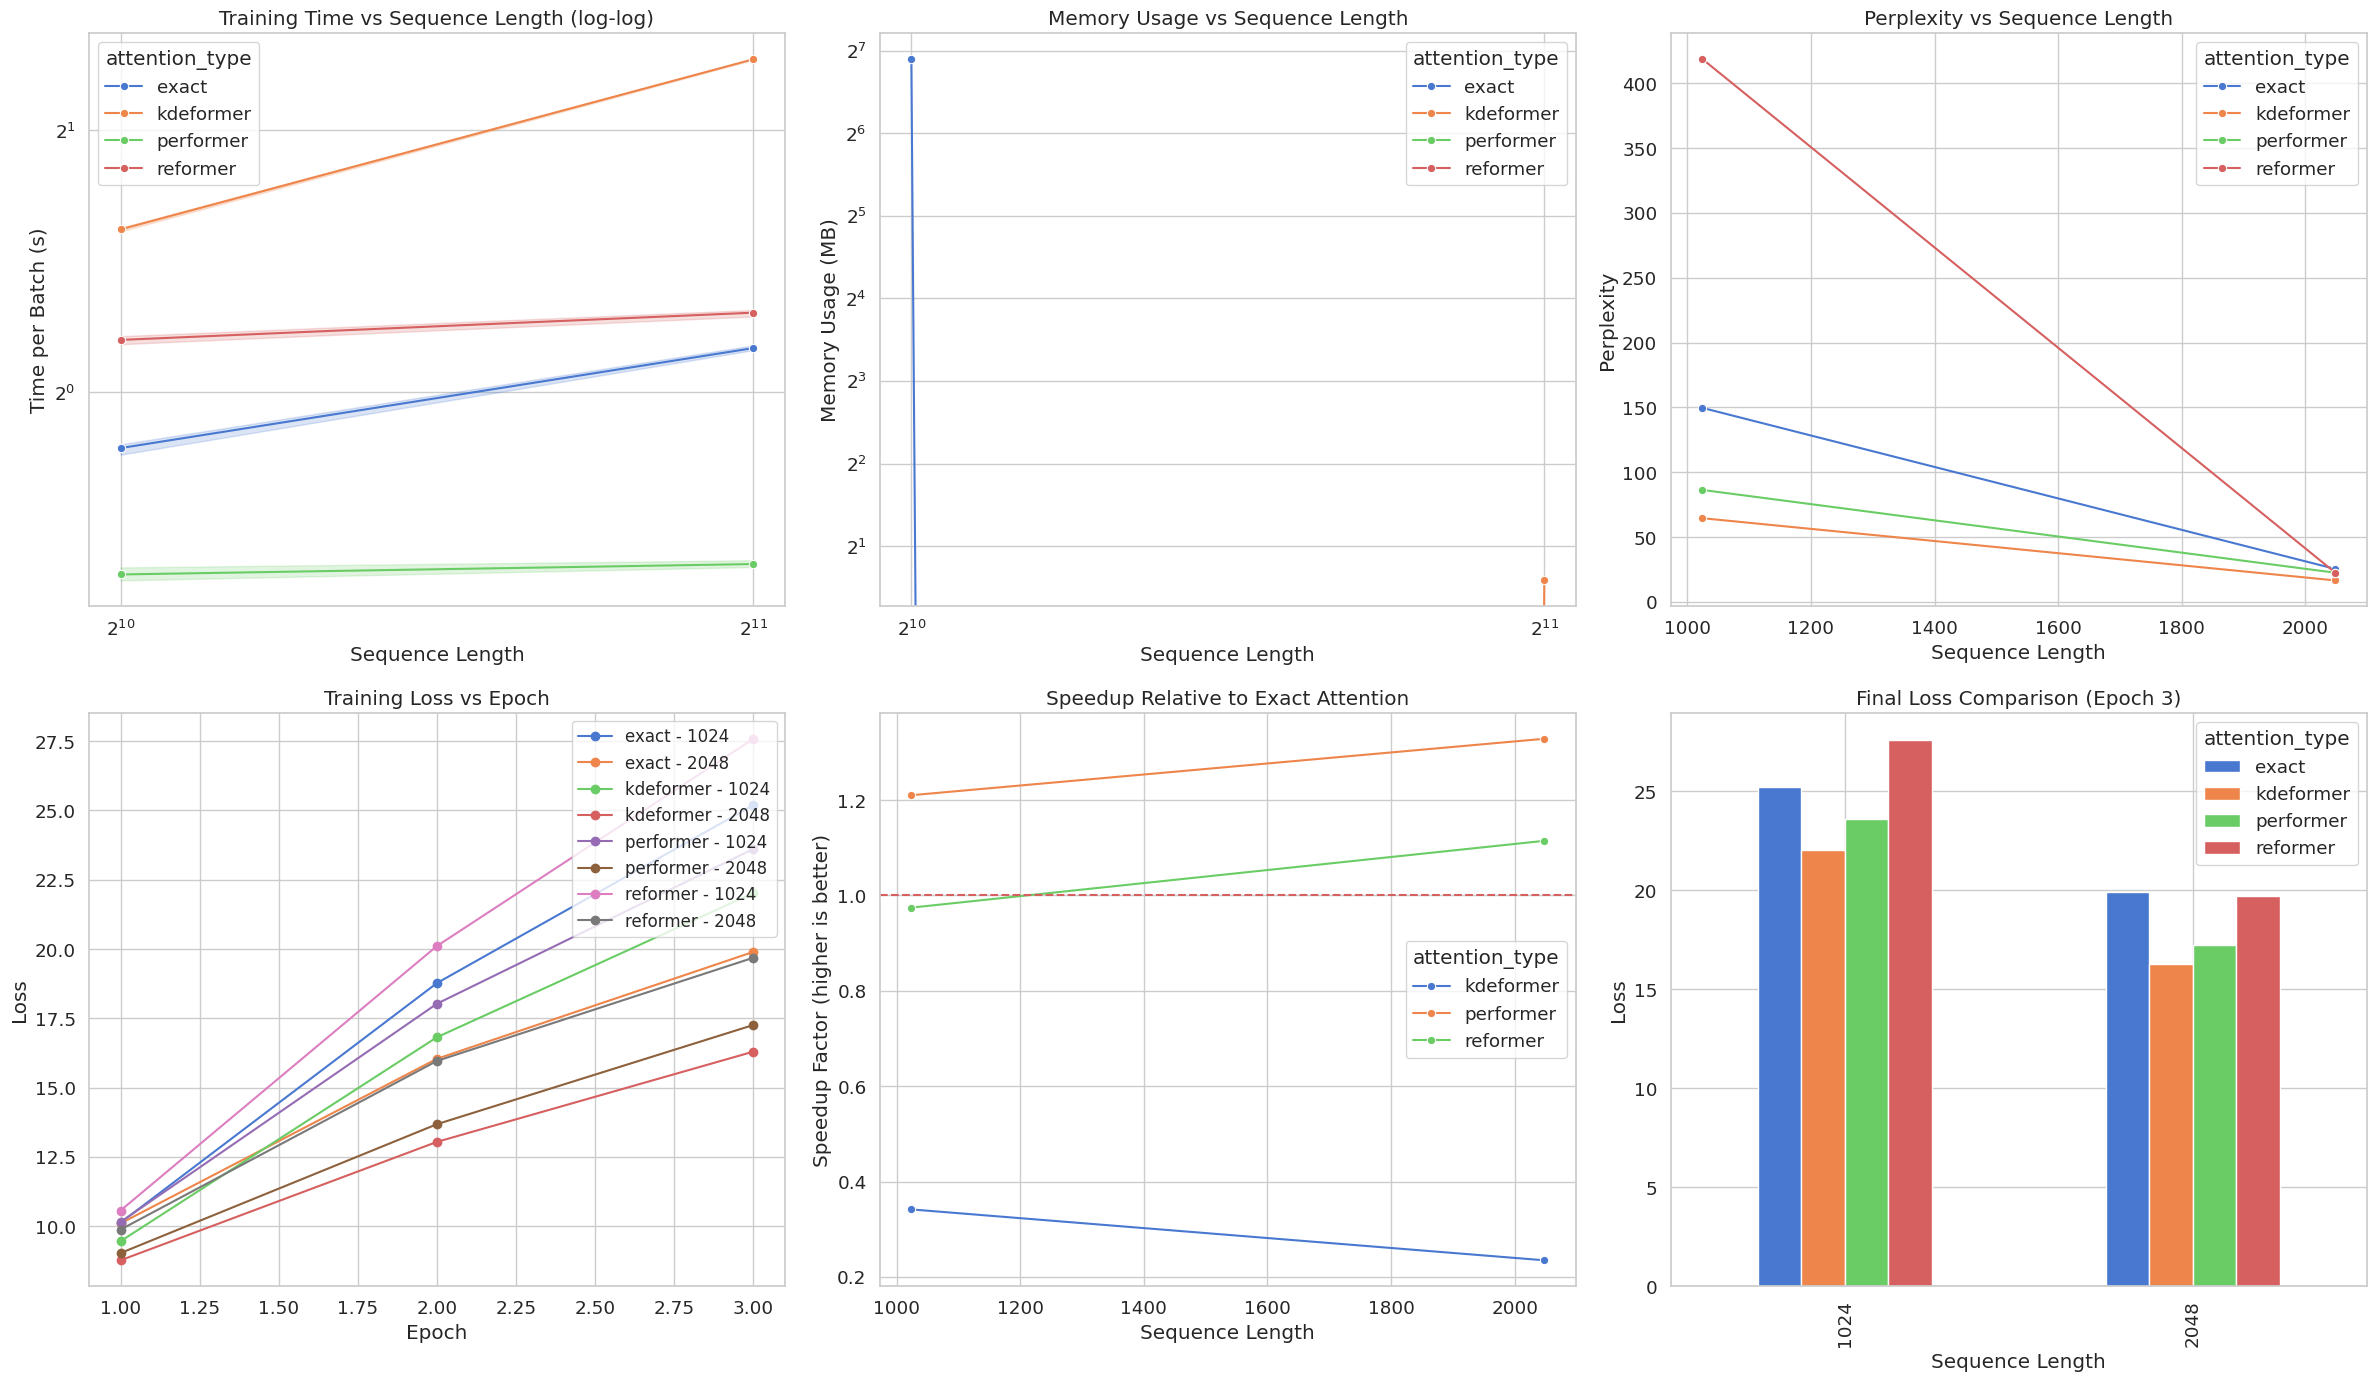


=== BENCHMARK RESULTS SUMMARY ===

Perplexity by attention type and sequence length:
sequence_length        1024       2048
attention_type                        
exact            149.704254  25.474550
kdeformer         64.594421  16.611576
performer         86.400826  22.534790
reformer         418.824615  22.651695

Evaluation time per batch (seconds):
sequence_length      1024      2048
attention_type                     
exact            0.404274  0.476111
kdeformer        1.183344  2.026683
performer        0.334037  0.358350
reformer         0.414834  0.427155

Memory usage (MB):
sequence_length        1024        2048
attention_type                         
exact            119.322754  -97.441895
kdeformer       -101.079102    1.500000
performer         -2.084473 -208.808105
reformer        -206.316895   -2.349609

Speedup relative to exact attention:
sequence_length      1024      2048
attention_type                     
kdeformer        0.341637  0.234921
performer        1.2

In [ ]:
# Load and visualize benchmark results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load results from CSV files
try:
    training_df = pd.read_csv('training_results.csv')
    eval_df = pd.read_csv('evaluation_results.csv')
    memory_df = pd.read_csv('memory_results.csv')

    # Try to load throughput and efficiency if they exist
    try:
        throughput_df = pd.read_csv('throughput_results.csv')
    except:
        throughput_df = pd.DataFrame()

    try:
        efficiency_df = pd.read_csv('efficiency_results.csv')
    except:
        efficiency_df = pd.DataFrame()

    # Create results dictionary for visualization
    results = {
        'training': training_df,
        'evaluation': eval_df,
        'memory': memory_df,
        'throughput': throughput_df,
        'efficiency': efficiency_df
    }

    # Set attractive plotting style
    sns.set(style="whitegrid", palette="muted", font_scale=1.2)
    plt.figure(figsize=(24, 20))

    # 1. Training time vs sequence length (log-log plot)
    plt.subplot(3, 3, 1)
    sns.lineplot(data=results['training'], x='sequence_length', y='avg_batch_time',
                 hue='attention_type', marker='o')
    plt.xscale('log', base=2)
    plt.yscale('log', base=2)
    plt.title('Training Time vs Sequence Length (log-log)')
    plt.xlabel('Sequence Length')
    plt.ylabel('Time per Batch (s)')
    plt.grid(True, which="both", ls="-")

    # 2. Memory usage vs sequence length
    plt.subplot(3, 3, 2)
    sns.lineplot(data=results['memory'], x='sequence_length', y='memory_used_mb',
                 hue='attention_type', marker='o')
    plt.xscale('log', base=2)
    plt.yscale('log', base=2)
    plt.title('Memory Usage vs Sequence Length')
    plt.xlabel('Sequence Length')
    plt.ylabel('Memory Usage (MB)')
    plt.grid(True, which="both", ls="-")

    # 3. Perplexity vs sequence length
    plt.subplot(3, 3, 3)
    sns.lineplot(data=results['evaluation'], x='sequence_length', y='perplexity',
                 hue='attention_type', marker='o')
    plt.title('Perplexity vs Sequence Length')
    plt.xlabel('Sequence Length')
    plt.ylabel('Perplexity')
    plt.grid(True)

    # 4. Training loss vs epoch
    plt.subplot(3, 3, 4)
    for attn_type in training_df['attention_type'].unique():
        for seq_len in training_df['sequence_length'].unique():
            subset = training_df[(training_df['attention_type'] == attn_type) &
                                (training_df['sequence_length'] == seq_len)]
            if not subset.empty:
                plt.plot(subset['epoch'], subset['loss'],
                        marker='o', label=f"{attn_type} - {seq_len}")
    plt.title('Training Loss vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(True)

    # 5. Calculate and plot speedup relative to exact attention
    plt.subplot(3, 3, 5)
    speedup_data = []
    for seq_len in eval_df['sequence_length'].unique():
        exact_time = eval_df[
            (eval_df['attention_type'] == 'exact') &
            (eval_df['sequence_length'] == seq_len)
        ]['eval_time_per_batch'].values

        if len(exact_time) == 0:
            continue

        exact_time = exact_time[0]

        for attn_type in eval_df['attention_type'].unique():
            if attn_type == 'exact':
                continue

            attn_times = eval_df[
                (eval_df['attention_type'] == attn_type) &
                (eval_df['sequence_length'] == seq_len)
            ]['eval_time_per_batch'].values

            if len(attn_times) == 0:
                continue

            attn_time = attn_times[0]
            speedup = exact_time / attn_time

            speedup_data.append({
                'sequence_length': seq_len,
                'attention_type': attn_type,
                'speedup': speedup
            })

    if speedup_data:
        speedup_df = pd.DataFrame(speedup_data)
        sns.lineplot(data=speedup_df, x='sequence_length', y='speedup',
                    hue='attention_type', marker='o')
        plt.title('Speedup Relative to Exact Attention')
        plt.xlabel('Sequence Length')
        plt.ylabel('Speedup Factor (higher is better)')
        plt.axhline(y=1.0, color='r', linestyle='--')
        plt.grid(True)

    # 6. Final loss comparison bar chart
    plt.subplot(3, 3, 6)
    max_epoch = training_df['epoch'].max()
    last_epoch_df = training_df[training_df['epoch'] == max_epoch]
    pivoted = last_epoch_df.pivot(index='sequence_length', columns='attention_type', values='loss')
    pivoted.plot(kind='bar', ax=plt.gca())
    plt.title(f'Final Loss Comparison (Epoch {max_epoch})')
    plt.xlabel('Sequence Length')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('kdeformer_benchmark_results.png', dpi=300)
    plt.show()

    # Print summary statistics
    print("\n=== BENCHMARK RESULTS SUMMARY ===\n")

    print("Perplexity by attention type and sequence length:")
    perplexity_table = pd.pivot_table(eval_df,
                                     values='perplexity',
                                     index='attention_type',
                                     columns='sequence_length')
    print(perplexity_table)

    print("\nEvaluation time per batch (seconds):")
    time_table = pd.pivot_table(eval_df,
                               values='eval_time_per_batch',
                               index='attention_type',
                               columns='sequence_length')
    print(time_table)

    print("\nMemory usage (MB):")
    memory_table = pd.pivot_table(memory_df,
                                 values='memory_used_mb',
                                 index='attention_type',
                                 columns='sequence_length')
    print(memory_table)

    if speedup_data:
        print("\nSpeedup relative to exact attention:")
        speedup_table = pd.pivot_table(pd.DataFrame(speedup_data),
                                      values='speedup',
                                      index='attention_type',
                                      columns='sequence_length')
        print(speedup_table)

    print("\nBest performing attention mechanism by sequence length:")
    for seq_len in eval_df['sequence_length'].unique():
        subset = eval_df[eval_df['sequence_length'] == seq_len]
        if not subset.empty:
            best_perplexity = subset.loc[subset['perplexity'].idxmin()]
            print(f"Seq length {seq_len}: {best_perplexity['attention_type']} (perplexity: {best_perplexity['perplexity']:.2f})")

except Exception as e:
    print(f"Error loading or visualizing results: {e}")
    print("Make sure you've run the benchmark and have CSV result files.")